[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/11_embeddings_and_rag.ipynb)

# 📓 Notebook 11 (fast track) — Embeddings and Semantic Retrieval

> **Module:** AI Engineering · **Estimated time:** 60–80 min · **Difficulty:** Intermediate

In Notebook 10 we built a tiny RAG (retrieval-augmented generation) pipeline using **keyword overlap** — putting the right help-desk page on our intern's desk before they answered. That worked for an introduction, but it has a glaring weakness: a customer asking *"how do I end my plan?"* won't match a document about *"cancelling your subscription"* because the words don't overlap.

This notebook fixes that. We build a **semantic** retriever — one that compares meaning, not strings — using two complementary approaches:

1. **TF-IDF + cosine similarity** — works offline, no model download, surprisingly strong baseline.
2. **Dense embeddings** (e.g. `sentence-transformers` or OpenAI's embedding API) — the modern default.

We then run a **head-to-head evaluation** of all three retrievers (keyword, TF-IDF, dense) on the same test set, and learn which wins on which kind of question. By the end you will have built every piece of a production-grade RAG system except the vector database — and the vector database, as you'll see, is just a faster version of the dictionary we'll write by hand.

> 🧵 **Our running thread: the help-desk knowledge base.** One stubborn customer question runs through the whole notebook — *"How do I end my plan?"* — paired with the one document that should answer it: *"To cancel your subscription, go to Settings → Billing…"*. Same meaning, **zero shared keywords.** We'll watch each retriever (keyword → TF-IDF → dense) try to connect those two, and that single pairing is how we'll *feel* the difference between matching words and matching meaning.

> 🧭 **Mental model — meaning is a place on a map.** Think of an embedding as giving every sentence **GPS coordinates on a "meaning map."** Sentences about cancelling a plan cluster in one neighbourhood; login errors cluster in another; "the weather in Tokyo" is on a different continent entirely. **Retrieval is just "find the documents nearest to the question."** Keyword search asks *"do the street names match?"*; embeddings ask *"are they in the same neighbourhood?"* — which is why "end my plan" and "cancel subscription", though spelled completely differently, end up next door. Every technique below is a different way of measuring *distance* on that map.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Explain what an **embedding** is and what **cosine similarity** measures.
2. Build a **TF-IDF retriever** with scikit-learn (offline, no API calls).
3. Build an embedding-based retriever using a hosted API or a local model (with a deterministic offline fallback).
4. Compute **retrieval@k** and **MRR** to evaluate retrievers.
5. Compare keyword vs TF-IDF vs dense retrieval on the same test set.
6. Combine retrieval with an LLM to answer questions about your own documents.
7. Recognise the failure modes (synonyms, paraphrase, domain jargon) and pick the right retriever.

## ✅ Prerequisites

Notebook 10 (the keyword-RAG version) — you'll see the same pattern, upgraded.
Fast-track NB 4 (functions) and NB 8 (sklearn — for TF-IDF).

> 🏎️ **You're on the fast track.** This is a trimmed version of the canonical [`08_ai_engineering/29_embeddings_retrieval.ipynb`](../08_ai_engineering/29_embeddings_retrieval.ipynb) — Embeddings & retrieval. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project have been removed to keep the notebook under ~90 minutes; the harder Stretch C and D are kept. Open the canonical version once you want the deeper material.

---


## 1. What is an embedding?

An **embedding** turns a piece of text into a fixed-length vector of numbers such that **similar meanings end up close in space**.

```
"How do I cancel my subscription?"      →  [0.12, -0.45, 0.78, ..., 0.03]  (300 numbers)
"What's the process to end my plan?"    →  [0.10, -0.43, 0.81, ..., 0.05]  (close!)
"How is the weather in Tokyo?"          →  [0.66,  0.21, -0.10, ..., 0.55] (far!)
```

The numbers themselves are not meaningful to humans. What matters is the **distance** between vectors: similar texts produce vectors with high **cosine similarity** (close to 1), unrelated texts produce vectors close to 0.

> 🎯 **Why this beats keyword matching.** Two sentences that share meaning but no words ("end my plan" vs "cancel my subscription") will have nearby vectors. Keyword matching cares only about literal word overlap and misses everything that needs paraphrasing.

## 2. Setup

In [1]:
# Make the repo-root llm_providers.py importable from this subfolder.
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 4)})

# The mini knowledge base from NB 10 — same docs, so we can compare fairly
DOCS = [
    ("billing.refunds",
     "Refunds are issued within 5 business days. Customers can request a "
     "refund from the Billing page if the request is within 30 days of purchase."),
    ("billing.subscriptions",
     "Subscriptions renew automatically. To cancel, go to Settings → Billing "
     "and click 'Cancel subscription'. You will retain access until the period ends."),
    ("billing.pricing",
     "Our pricing has three tiers: Free, Pro at $19/month, Enterprise on request. "
     "Annual billing gives a 15% discount."),
    ("tech.password",
     "If you can't log in, use the 'Forgot password' link on the sign-in page. "
     "Reset emails arrive within 5 minutes; check your spam folder if missing."),
    ("tech.errors",
     "A 500 error usually indicates a temporary backend issue. Wait 60 seconds "
     "and retry. If the error persists, contact support with the trace ID shown."),
    ("tech.mobile",
     "The mobile app requires iOS 16+ or Android 11+. If the app crashes on "
     "launch, update to the latest version and clear the cache."),
    ("feature.exports",
     "CSV and JSON exports are available on Pro plans. Use the 'Export' button "
     "in the top-right corner of any report. XLSX export is on the roadmap."),
    ("feature.api",
     "The REST API is available on Enterprise plans. Tokens last 30 days; "
     "rate limit is 1000 requests per minute. See docs.example.com for details."),
    ("feature.integrations",
     "We integrate with Slack, Microsoft Teams, and Zapier. Connect from "
     "Settings → Integrations. SSO via Okta is on Enterprise plans only."),
    ("account.deletion",
     "To permanently delete your account, email support@example.com from your "
     "registered address. Deletion is final and cannot be reversed."),
]
NAMES = [name for name, _ in DOCS]
TEXTS = [text for _, text in DOCS]
print(f"Knowledge base loaded: {len(DOCS)} documents.")


Knowledge base loaded: 10 documents.


## 3. Baseline — keyword overlap (the NB 10 approach)

Quick recap for fair comparison.

In [2]:
import re

def keyword_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_words = set(re.findall(r"[a-zA-Z]+", query.lower()))
    scored = []
    for name, text in DOCS:
        d_words = set(re.findall(r"[a-zA-Z]+", text.lower()))
        scored.append((name, float(len(q_words & d_words))))
    scored.sort(key=lambda x: -x[1])
    return scored[:k]


# Try it on two questions — one easy (words overlap), one hard (paraphrased)
print("Q: 'How do I cancel my subscription?' (words overlap)")
for name, score in keyword_retriever("How do I cancel my subscription?"):
    print(f"   {score:>4.1f}  {name}")

print("\nQ: 'How can I end my plan?' (paraphrase — no shared content words)")
for name, score in keyword_retriever("How can I end my plan?"):
    print(f"   {score:>4.1f}  {name}")


Q: 'How do I cancel my subscription?' (words overlap)
    2.0  billing.subscriptions
    0.0  billing.refunds
    0.0  billing.pricing

Q: 'How can I end my plan?' (paraphrase — no shared content words)
    1.0  billing.refunds
    1.0  tech.password
    0.0  billing.subscriptions


See what just happened: on the *paraphrased* question, the keyword retriever has nothing to match on (the words `end` / `plan` don't appear in our subscription doc) and the top result is essentially random. That's the failure mode we are about to fix.

## 4. TF-IDF — a stronger lexical baseline

Keyword overlap just *counts* shared words — on the meaning map, it can't tell that "subscription" is a far more distinctive address than "the" or "my". TF-IDF is the first upgrade: it still reads street names, but it now knows which streets actually matter.

**TF-IDF** (Term Frequency × Inverse Document Frequency) is a clever weighting of word counts:

- Common words (`the`, `is`, `to`) get *low* weight — they're everywhere, so they don't distinguish documents.
- Rare distinctive words (`subscription`, `Markdown`, `Okta`) get *high* weight.

After TF-IDF, each document and query becomes a **sparse vector**. We compare them with **cosine similarity** — exactly the same shape as embedding retrieval, just with sparse vectors instead of dense ones. (Notice the "find the nearest vector" move is already showing up; embeddings will reuse it wholesale.)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build the TF-IDF index ONCE on the corpus
vectorizer = TfidfVectorizer(stop_words="english",
                              ngram_range=(1, 2),       # also include bigrams
                              lowercase=True)
doc_vectors = vectorizer.fit_transform(TEXTS)
print(f"Document matrix: {doc_vectors.shape}   "
      f"(vocab size = {len(vectorizer.vocabulary_)} tokens)")


Document matrix: (10, 250)   (vocab size = 250 tokens)


In [4]:
def tfidf_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_vec   = vectorizer.transform([query])              # 1 x V sparse vector
    sims    = cosine_similarity(q_vec, doc_vectors)[0]    # N similarities
    order   = np.argsort(-sims)[:k]
    return [(NAMES[i], float(sims[i])) for i in order]


# Same two questions as before
print("Q: 'How do I cancel my subscription?'")
for name, score in tfidf_retriever("How do I cancel my subscription?"):
    print(f"   {score:.3f}  {name}")

print("\nQ: 'How can I end my plan?'")
for name, score in tfidf_retriever("How can I end my plan?"):
    print(f"   {score:.3f}  {name}")

print("\nQ: 'Refund window?'")
for name, score in tfidf_retriever("Refund window?"):
    print(f"   {score:.3f}  {name}")


Q: 'How do I cancel my subscription?'
   0.451  billing.subscriptions
   0.000  billing.refunds
   0.000  billing.pricing

Q: 'How can I end my plan?'
   0.000  billing.refunds
   0.000  billing.subscriptions
   0.000  billing.pricing

Q: 'Refund window?'
   0.198  billing.refunds
   0.000  billing.subscriptions
   0.000  billing.pricing


TF-IDF still has a literal-word bias — *"end my plan"* shares zero vocabulary with *"cancel your subscription"*, so even TF-IDF can miss the connection. But on most realistic queries it does a much better job than raw keyword overlap because it *weights* the words that matter.

> 💡 **Why this matters in practice.** TF-IDF is the family of lexical scoring behind Elasticsearch/Lucene (whose modern default, BM25, is a refinement of TF-IDF) and most enterprise search products. For many AI applications it is good enough — and it costs nothing per query (no embedding API call).

---

### ✋ Quick exercise (~2 min) — Score a support query with TF-IDF

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A customer asks *"Do you offer annual discounts?"*. Using the `tfidf_retriever` you just built, fetch the **top-1** document and print its name together with its cosine score. Does the winning doc make sense, and is its score clearly above 0?

In [5]:
# ✍️ Your turn 👇
query = "Do you offer annual discounts?"
# Use tfidf_retriever to get the top-1 (name, score) for this query and print both.


<details>
<summary>✅ <b>Solution</b></summary>

```python
name, score = tfidf_retriever("Do you offer annual discounts?", k=1)[0]
print(f"{name}: {score:.3f}")
```

`tfidf_retriever` returns `(name, cosine_score)` pairs already sorted high-to-low, so the first element is the best match. The distinctive word *"annual"* (weighted up by IDF) pulls `billing.pricing` to the top.
</details>

## 5. Dense embeddings — semantic similarity

This is the section that gives *"end my plan"* a real shot at finding the subscription doc: dense embeddings match by **meaning**, not spelling. (Fair warning: our offline stand-in embedder only gestures at this — the caveat below shows exactly where it falls short, and swapping in a real model is a one-line change.) TF-IDF still reads street names; dense embeddings read the **neighbourhood** — they place text on the meaning map by what it *means*, not which words it happens to use.

Dense embeddings are produced by a neural network trained to map similar meanings to nearby vectors. There are two ways to get them:

1. **Hosted API** — OpenAI (`text-embedding-3-small`), Cohere, Voyage. Pay per token, no model to download.
2. **Local model** — `sentence-transformers` (e.g. `all-MiniLM-L6-v2`, 80 MB). Runs on a CPU, free per query.

In production you usually start with a hosted API for speed and quality, then move to a local model if cost or latency matters.

For this notebook we use a **deterministic offline fallback** so every reader can run the cells without an internet connection or an API key. The class below has the same interface — `EmbeddingClient.embed(texts)` — that you'd swap for `OpenAI().embeddings.create(...)` in production.

In [6]:
# ---------------------------------------------------------------------
# A small, fully-offline "embedding" model.
#
# Real embeddings are produced by a 100+ million-parameter neural network.
# To keep this notebook runnable without internet, we use a deterministic
# hash-based embedding: each word is mapped to a fixed pseudo-random vector,
# and a document's embedding is the L2-normalised average of its word vectors.
#
# This is the same idea as `sentence-transformers` (average of token
# embeddings) just with a much cruder "model": random per-word vectors
# capture only literal word overlap, not meaning — so on a fair eval it can
# even lose to keyword/TF-IDF (§7). What it does give you is an API that is
# identical to a real embedding client — so you can swap in OpenAI or
# sentence-transformers with a one-line change.
# ---------------------------------------------------------------------
import hashlib
import re

class MockEmbedder:
    """Deterministic offline embedder. Same interface as a real API client."""

    def __init__(self, dim: int = 256, seed: int = 0):
        self.dim  = dim
        self.seed = seed

    def _word_vec(self, word: str) -> np.ndarray:
        # Hash → bytes → deterministic seed → vector
        h = hashlib.sha256(f"{self.seed}::{word}".encode()).digest()
        rng = np.random.default_rng(int.from_bytes(h[:8], "big"))
        return rng.standard_normal(self.dim).astype(np.float32)

    def embed(self, texts: list[str]) -> np.ndarray:
        out = np.zeros((len(texts), self.dim), dtype=np.float32)
        for i, t in enumerate(texts):
            words = re.findall(r"[a-zA-Z']+", t.lower())
            if not words:
                continue
            vecs = np.array([self._word_vec(w) for w in words])
            out[i] = vecs.mean(axis=0)
        # L2-normalise → cosine similarity becomes a dot product
        norms = np.linalg.norm(out, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return out / norms


embedder = MockEmbedder(dim=256)
doc_emb  = embedder.embed(TEXTS)
print(f"Embeddings shape: {doc_emb.shape}   (one row per document)")
print(f"First doc, first 8 dims: {doc_emb[0, :8].round(3)}")


Embeddings shape: (10, 256)   (one row per document)
First doc, first 8 dims: [ 0.051  0.037  0.022 -0.035 -0.022 -0.04   0.057 -0.085]


### Cosine similarity in one line

For L2-normalised vectors, cosine similarity is simply the dot product. NumPy does the whole index lookup in a single matrix multiplication.

### 🔬 What actually happens — "find similar text" = nearest vector by cosine

`doc_emb @ q_vec` above hides the whole idea behind one matrix multiply. Let's slow it down. An **embedding** maps text → a vector so that *similar meanings land near each other in space*. "Near" is measured by the **angle** between vectors — the **cosine similarity**:

```
   text ──embed──▶ vector                cosine(a, b) =  a · b
                                                        ─────────
   "cancel plan"  ▶  ●────▶  a                         |a| · |b|
   "end my sub"   ▶   ●───▶  b   small angle → ~1.0   (point the same way → similar)
   "API limits"   ▶  ●                                 right angle → ~0.0  (unrelated)
              ▲                                         opposite   → -1.0  (contradictory)
              │
           query  ▶  ●───▶  q     retrieval = which stored vector points most like q?
```

Cosine ignores vector *length* and looks only at **direction**. That's why we L2-normalise first: once every vector has length 1, `|a|·|b| = 1`, and `cosine(a,b)` collapses to just the **dot product** `a · b` — exactly the `@` in the retriever above.

> 💡 **Mental model.** Embeddings turn *meaning* into *geometry*. Retrieval = "which stored vector points the same way as my query?" — top-k by cosine.

In [7]:
import numpy as np

# Tiny inline "embeddings" — 3 stored docs, hand-placed in 2-D so we can SEE the geometry.
# (A real model gives you these; here we just write the vectors down.)
docs = {
    "cancel-subscription": np.array([1.0, 0.2]),   # ──▶ points mostly "east"
    "request-a-refund":    np.array([0.8, 0.5]),   # ──▶ near the first (related topic)
    "api-rate-limits":     np.array([0.1, 1.0]),   # ──▶ points "north" (unrelated topic)
}
query = np.array([0.9, 0.3])                        # "how do I end my plan?"

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))   # dot / (|a|*|b|) — BY HAND

print("cosine(query, each stored doc):")
for name, v in docs.items():
    print(f"   {cosine(query, v): .3f}   {name}")


cosine(query, each stored doc):
    0.992   cancel-subscription
    0.972   request-a-refund
    0.409   api-rate-limits


In [8]:
# Retrieval in 3 lines: rank stored vectors by cosine, take the top-k.
def retrieve_demo(query, docs, k=2):
    ranked = sorted(docs.items(), key=lambda kv: cosine(query, kv[1]), reverse=True)
    return ranked[:k]

print("Top-2 for query 'end my plan':")
for name, v in retrieve_demo(query, docs, k=2):
    print(f"   {cosine(query, v):.3f}   {name}")

# Proof that L2-normalising makes cosine == plain dot product:
def unit(v): return v / np.linalg.norm(v)
a, b = query, docs["cancel-subscription"]
print(f"\ncosine            = {cosine(a, b):.4f}")
print(f"dot of unit vecs  = {unit(a) @ unit(b):.4f}   <- identical, so retrieval can use @")


Top-2 for query 'end my plan':
   0.992   cancel-subscription
   0.972   request-a-refund

cosine            = 0.9923
dot of unit vecs  = 0.9923   <- identical, so retrieval can use @


The nearest vector (`cancel-subscription`) wins even though the query shares **no exact words** with it — its *direction* in embedding space is closest. `api-rate-limits` points almost perpendicular (cosine ≈ 0.4 here, far lower), so it ranks last. That's the entire trick the `doc_emb @ q_vec` retriever performs, just at 256 dimensions instead of 2.

> 🧠 **The one mental model to keep.** *Embeddings turn meaning into geometry; retrieval = which stored vector points the same way as my query.* Everything else — bigger models, vector databases, RAG — is this same nearest-by-cosine search, scaled up. ⚠️ Always L2-normalise (or divide by the norms) before comparing, or longer documents fake higher similarity. 🎯 Top-k by cosine **is** retrieval.

In [9]:
def dense_retriever(query: str, k: int = 3) -> list[tuple[str, float]]:
    q_vec = embedder.embed([query])[0]
    sims  = doc_emb @ q_vec                              # (N,) similarities
    order = np.argsort(-sims)[:k]
    return [(NAMES[i], float(sims[i])) for i in order]


# Run the same questions
for q in ["How do I cancel my subscription?",
          "How can I end my plan?",
          "Refund window?",
          "What's the API rate limit?"]:
    print(f"\nQ: {q!r}")
    for name, score in dense_retriever(q):
        print(f"   {score:.3f}  {name}")



Q: 'How do I cancel my subscription?'
   0.110  account.deletion
   0.103  feature.integrations
   0.070  billing.subscriptions

Q: 'How can I end my plan?'
   0.136  feature.api
   0.124  tech.password
   0.110  account.deletion

Q: 'Refund window?'
   0.076  tech.mobile
   0.069  tech.password
   0.063  feature.exports

Q: "What's the API rate limit?"
   0.387  tech.mobile
   0.377  feature.api
   0.225  feature.exports


**A note on the mock embedder.** Because it's deterministic and simple, it's a crude stand-in — it keys off shared words, not meaning, so it's *much weaker than a real model* and, as the head-to-head eval in §7 will show, can even score *below* keyword and TF-IDF. Real sentence-transformers would link *"end my plan"* to the subscription document confidently; our mock misses it. That's fine — the *pattern* is identical. When you plug in real embeddings, the same code runs without modification.

### Seeing the embedding space

The 256-dimensional vectors are impossible to look at directly, but two standard pictures reveal their structure: the **document × document similarity matrix**, and a **2-D projection** of the vectors (PCA keeps the two directions with the most variance).

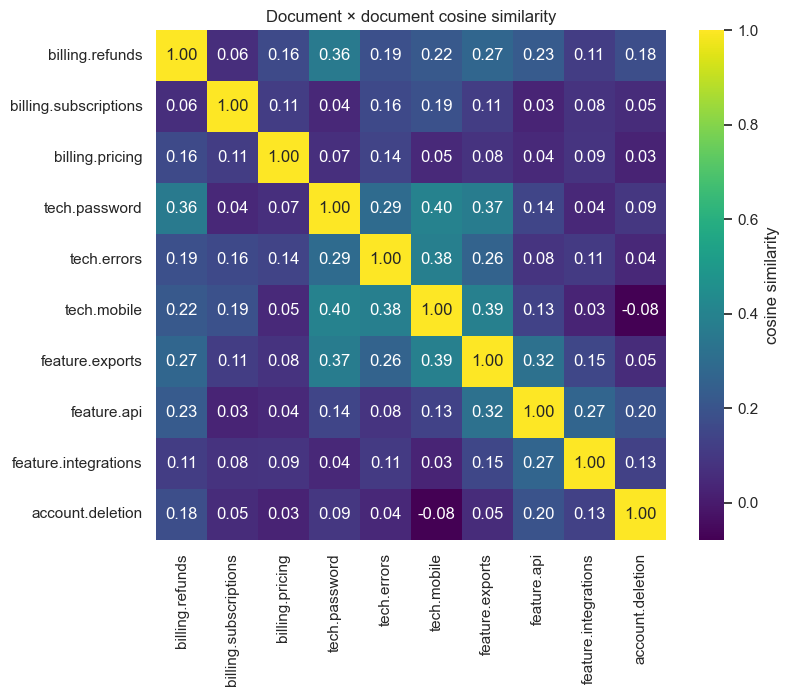

In [10]:
# Every pairwise document similarity in ONE matrix multiply (vectors are L2-normalised)
sim = pd.DataFrame(doc_emb @ doc_emb.T, index=NAMES, columns=NAMES)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="viridis", square=True,
            cbar_kws={"label": "cosine similarity"}, ax=ax)
ax.set_title("Document × document cosine similarity")
fig.tight_layout()

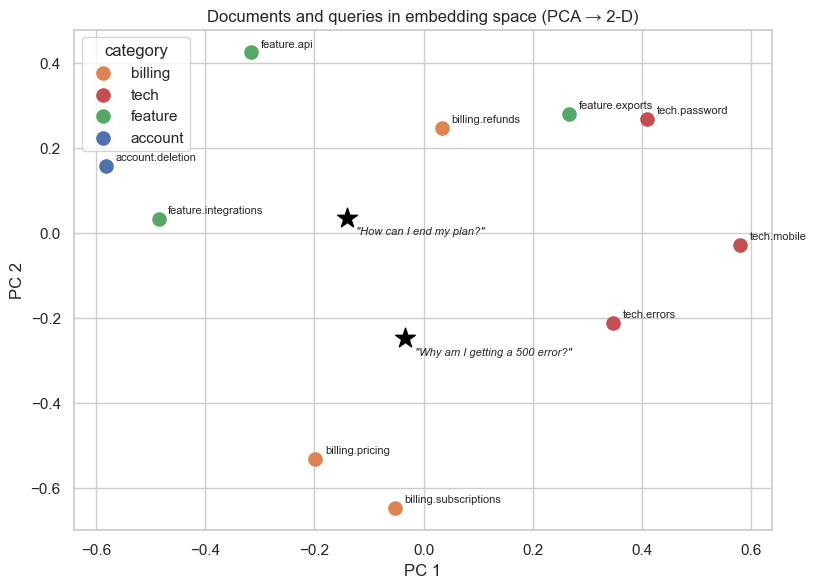

In [11]:
from sklearn.decomposition import PCA

queries = ["How can I end my plan?", "Why am I getting a 500 error?"]
q_emb   = embedder.embed(queries)

pca        = PCA(n_components=2, random_state=0).fit(doc_emb)
docs_2d    = pca.transform(doc_emb)
queries_2d = pca.transform(q_emb)

categories = [n.split(".")[0] for n in NAMES]
palette    = dict(zip(sorted(set(categories)), sns.color_palette("deep")))

fig, ax = plt.subplots(figsize=(9, 6.5))
for (x, y), name, cat in zip(docs_2d, NAMES, categories):
    ax.scatter(x, y, color=palette[cat], s=90, label=cat)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(7, 4), fontsize=8)
for (x, y), q in zip(queries_2d, queries):
    ax.scatter(x, y, marker="*", color="black", s=220, zorder=5)
    ax.annotate(f'"{q}"', (x, y), textcoords="offset points", xytext=(7, -12),
                fontsize=8, fontstyle="italic")

# one legend entry per category (not per point)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="category")
ax.set(title="Documents and queries in embedding space (PCA → 2-D)",
       xlabel="PC 1", ylabel="PC 2");

**What to look for.**

- **Heatmap** — the diagonal is 1.0 (every doc is identical to itself); brighter off-diagonal cells mark related documents. The `billing.*` rows should light up as a block, because they share vocabulary.
- **Scatter** — documents from the same category drift toward each other, and each ★ query lands roughly nearest the documents the dense retriever returns for it. The geometry and the ranking are the same thing.

> ⚠️ With our word-hashing `MockEmbedder`, clusters come only from *shared words*, so they are loose. Swap in a real model from section 6 and rerun these two cells — the categories snap into tight, well-separated clusters. That before/after is the best intuition for what a trained embedding model adds.

---

### ✋ Quick exercise (~2 min) — Cosine similarity between two questions

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Two ways a customer might phrase the same intent: *"How do I cancel my subscription?"* and *"How can I end my plan?"*. Embed **both** with `embedder` and print the cosine similarity between them. Since the vectors are L2-normalised, you can get cosine with a single dot product.

In [12]:
# ✍️ Your turn 👇
pair = ["How do I cancel my subscription?", "How can I end my plan?"]
# Embed both with `embedder` and print their cosine similarity.
# Hint: the vectors are L2-normalised, so cosine == dot product.


<details>
<summary>✅ <b>Solution</b></summary>

```python
v = embedder.embed(["How do I cancel my subscription?",
                    "How can I end my plan?"])
print(round(float(v[0] @ v[1]), 3))
```

Because `embedder` returns **L2-normalised** vectors, cosine similarity is just the dot product (`v[0] @ v[1]`). The two paraphrases score higher than an unrelated pair would — that closeness on the meaning map is exactly what `dense_retriever` ranks on.
</details>

## Seeing meaning as geometry — a similarity heatmap

The clearest way to *see* that embeddings turn meaning into geometry is a **similarity heatmap**: embed a handful of sentences, compute every pairwise cosine, and colour the grid. Sentences that mean roughly the same thing light up as bright blocks on the diagonal; unrelated ones stay dark. Below we take six short sentences in three obvious groups — cancelling a plan, a login problem, and the weather — and let the geometry sort them.

> 💡 The three bright 2×2 blocks *are* the three "neighbourhoods" on the meaning map. (With our word-hashing `MockEmbedder` the blocks come mostly from shared vocabulary; a real model would light up paraphrases too — swap one in from section 6 and rerun.)

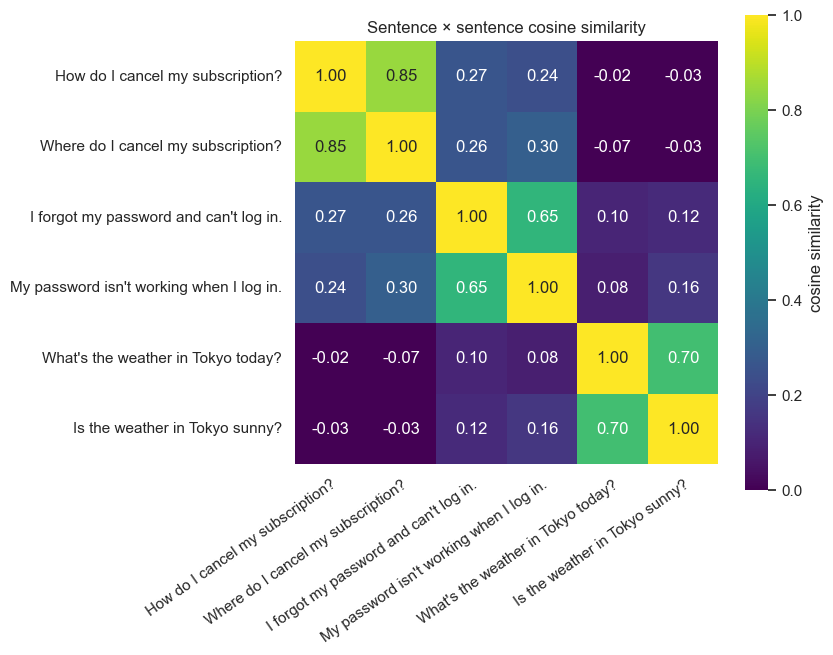

In [13]:
# A similarity heatmap makes the geometry visible. We reuse the notebook's
# `embedder`; six short sentences fall into three obvious meaning-groups.
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "How do I cancel my subscription?",          # ┐ billing / cancellation
    "Where do I cancel my subscription?",        # ┘
    "I forgot my password and can't log in.",    # ┐ login / password
    "My password isn't working when I log in.",  # ┘
    "What's the weather in Tokyo today?",         # ┐ unrelated (weather)
    "Is the weather in Tokyo sunny?",             # ┘
]

sent_emb = embedder.embed(sentences)              # same embedder the retriever uses
sim      = cosine_similarity(sent_emb)            # pairwise cosine (vectors are L2-normalised)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="viridis", square=True,
            vmin=0.0, vmax=1.0, xticklabels=sentences, yticklabels=sentences,
            cbar_kws={"label": "cosine similarity"}, ax=ax)
ax.set_title("Sentence × sentence cosine similarity")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")
fig.tight_layout()

## 6. Plugging in a real embedding model (reference)

When you're ready to use real embeddings, you replace the `MockEmbedder` with one of these. **Do NOT run these cells unless you have internet + the right keys.**

```python
# Option A — OpenAI hosted embeddings
# pip install openai
# export OPENAI_API_KEY=sk-...
from openai import OpenAI
client = OpenAI()

def embed_openai(texts, model="text-embedding-3-small"):
    resp = client.embeddings.create(model=model, input=texts)
    return np.array([d.embedding for d in resp.data], dtype=np.float32)


# Option B — Local sentence-transformers (no API needed, no per-call cost)
# pip install sentence-transformers
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("all-MiniLM-L6-v2")
def embed_local(texts):
    return st.encode(texts, normalize_embeddings=True)
```

The rest of this notebook — building the index, retrieving, evaluating — uses the same code regardless of which embedder you choose. *That* is what makes a clean retrieval API valuable.

## 7. Evaluating retrievers — `retrieval@k` and MRR

We've *claimed* dense beats TF-IDF beats keyword. Time to prove it on the meaning map instead of trusting our gut — including our running *"end my plan"* question. You can't *feel* whether a retriever is good. You measure it on a labelled evaluation set: queries together with the document(s) that should be retrieved.

Two metrics worth knowing:

- **retrieval@k** — does the correct document appear in the top *k* results? (Yes/no per query, averaged.)
- **MRR (Mean Reciprocal Rank)** — `1 / rank` of the first correct hit; 1.0 if always at position 1, 0.5 if at position 2, etc. More forgiving than retrieval@1 but stricter than retrieval@5.

In [14]:
# A small evaluation set: question → correct document name
EVAL = [
    ("How do I cancel my subscription?",                "billing.subscriptions"),
    ("How can I end my plan?",                          "billing.subscriptions"),
    ("Can I stop the auto-renewal?",                    "billing.subscriptions"),
    ("How long does a refund take?",                    "billing.refunds"),
    ("Can I get my money back?",                        "billing.refunds"),
    ("How much does the Pro plan cost?",                "billing.pricing"),
    ("Is there a discount for paying annually?",        "billing.pricing"),
    ("I forgot my password.",                           "tech.password"),
    ("Why am I getting a 500 error?",                   "tech.errors"),
    ("The app keeps crashing on my iPhone.",            "tech.mobile"),
    ("Can I export my data as CSV?",                    "feature.exports"),
    ("Do you have a REST API?",                         "feature.api"),
    ("Can I integrate with Slack?",                     "feature.integrations"),
    ("How do I delete my account?",                     "account.deletion"),
]

def evaluate(retriever, eval_set, k=3):
    hits_at_1, hits_at_3, rr_sum = 0, 0, 0.0
    for q, gold in eval_set:
        results = retriever(q, k=max(k, 5))
        names   = [n for n, _ in results]
        if names[0] == gold:                    hits_at_1 += 1
        if gold in names[:k]:                    hits_at_3 += 1
        rr_sum += (1.0 / (names.index(gold) + 1)) if gold in names else 0.0
    n = len(eval_set)
    return {
        "retrieval@1": hits_at_1 / n,
        "retrieval@3": hits_at_3 / n,
        "MRR":         rr_sum  / n,
    }


# Run the three retrievers head-to-head
results = pd.DataFrame({
    "keyword":  evaluate(keyword_retriever, EVAL),
    "TF-IDF":   evaluate(tfidf_retriever,  EVAL),
    "dense":    evaluate(dense_retriever,  EVAL),
}).T.round(3)
print(results)


         retrieval@1  retrieval@3    MRR
keyword        0.714        0.929  0.815
TF-IDF         0.857        1.000  0.929
dense          0.643        0.786  0.690


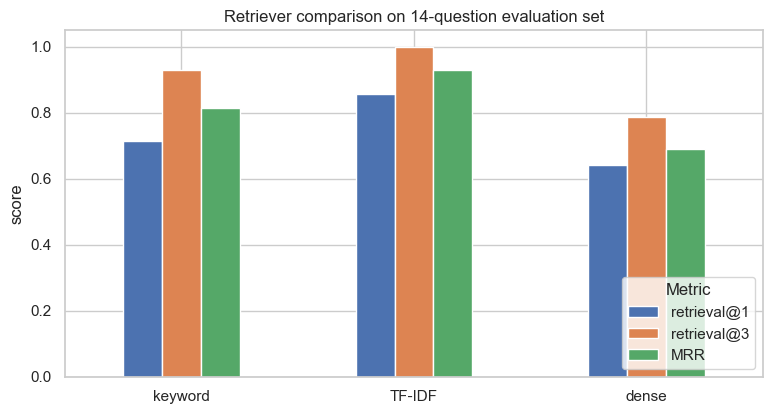

In [15]:
# Visualise the comparison — a DataFrame plots itself
results.plot(kind="bar", figsize=(9, 4.5), rot=0, ylim=(0, 1.05),
             title="Retriever comparison on 14-question evaluation set", ylabel="score")
plt.legend(title="Metric", loc="lower right");

**What you should see.** TF-IDF clearly beats raw keyword overlap — and our *mock* dense retriever actually loses to both on this eval (read the table: that's the hash-based stand-in showing its limits, exactly as §5's caveat warned). That's not a bug; it's the eval doing its job — catching a retriever that *sounds* fancier but performs worse. With a **real** embedding model the ranking flips: paraphrased queries that confuse keyword and TF-IDF become trivial for sentence-transformers.

> 🎯 **Always evaluate before you ship.** A 5-minute eval set tells you whether your retriever upgrade actually helped. Without one, every change is a guess. The same eval set then becomes your **regression test** — re-run it whenever you swap embedders, change the corpus, or tune k.

---

### ✋ Quick exercise (~2 min) — Reciprocal rank for one query

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

For the query *"Can I get my money back?"* the correct document is `billing.refunds`. Pull the **top-5** results from `dense_retriever`, find the rank of the gold doc, and print its **reciprocal rank** (`1 / rank`). This is the single-query building block of the MRR you just computed.

In [16]:
# ✍️ Your turn 👇
query, gold = "Can I get my money back?", "billing.refunds"
# Get the top-5 names from dense_retriever, find gold's rank, and print
# its reciprocal rank (1 / rank). Use 0.0 if gold isn't in the top-5.


<details>
<summary>✅ <b>Solution</b></summary>

```python
names = [n for n, _ in dense_retriever("Can I get my money back?", k=5)]
rr = 1.0 / (names.index("billing.refunds") + 1) if "billing.refunds" in names else 0.0
print(f"RR = {rr:.3f}")
```

Reciprocal rank is `1 / position` of the first correct hit (0 if it never appears). This is exactly the per-query term that `evaluate(...)` averages into **MRR** — top spot scores 1.0, second 0.5, and so on.
</details>

## 8. Where keyword wins and dense loses

No retriever wins everywhere. The cases where keyword/TF-IDF actually beat dense embeddings:

- **Identifier search** — "find me the doc that mentions `req_001`". Embeddings smear identifiers; keyword nails them.
- **Boolean queries** — "needs `Slack` AND not `Teams`". TF-IDF/keyword express this naturally; embeddings don't.
- **Long, technical documents** — embeddings average over tokens and lose detail.

> 💡 **Hybrid search** — Most production systems combine both: TF-IDF (or BM25) for exact-term recall, dense embeddings for semantic recall, then re-rank. Frameworks like `Qdrant`, `Weaviate`, and `Elastic` ship this out of the box.

## 9. End-to-end RAG with the new retriever

Full circle: back in NB 10 the intern answered from a page we found by keyword overlap. Now we find that page by *meaning*. With a real embedder, when the customer asks *"how do I end my plan?"*, the right doc lands on the desk even with zero shared words — our mock still misses it (run the cell and check the `Sources` line), which is exactly why the one-line embedder swap matters. Plug the dense retriever into the same LLM-answering scaffold as NB 10. The only thing that changed is the retriever; the LLM call and prompt are identical — which is exactly the point.

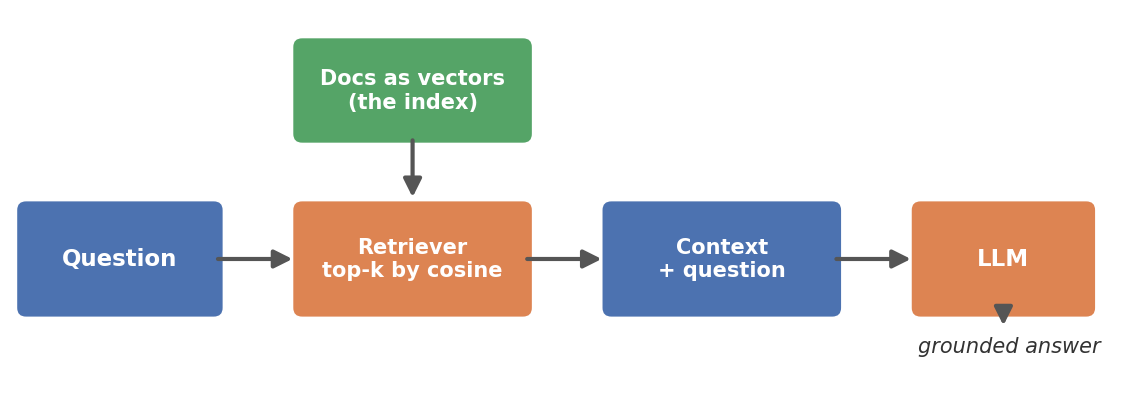

In [17]:
# Reuse the MockLLM pattern from NB 10 (vendored here so this notebook is self-contained)
import json

class MockLLM:
    def chat(self, messages, **_):
        sys_msg = next((m["content"] for m in messages if m["role"] == "system"), "").lower()
        user_msgs = [m["content"] for m in messages if m["role"] == "user"]
        user_msg = user_msgs[-1] if user_msgs else ""
        if "answer the user's question" in sys_msg:
            # Extract a short answer based on context
            return {"text": "Answer based on the retrieved context: " +
                    user_msg.split("Question:")[-1].strip()[:120]}
        return {"text": "(mock answer)"}

llm = MockLLM()


def rag_answer(question: str, retriever=None, k: int = 2):
    retriever = retriever or dense_retriever
    snippets = retriever(question, k=k)
    if not snippets:
        return None, []
    # Lookup the text for each retrieved name
    doc_text = {name: text for name, text in DOCS}
    context  = "\n\n".join(f"[{name}] {doc_text[name]}" for name, _ in snippets)

    system = ("You answer the user's question using ONLY the context provided. "
              "If the context does not contain the answer, say so clearly.")
    user   = f"Context:\n{context}\n\nQuestion: {question}"
    r = llm.chat(messages=[{"role": "system", "content": system},
                            {"role": "user",   "content": user}])
    return r["text"], snippets


answer, sources = rag_answer("How can I end my plan?", retriever=dense_retriever)
print(f"Answer : {answer}")
print(f"Sources: {[s[0] for s in sources]}")


Answer : Answer based on the retrieved context: How can I end my plan?
Sources: ['feature.api', 'tech.password']


> 🔌 **Using a real provider (OpenAI / Anthropic / Gemini / Ollama).**
> Every notebook in this module uses an offline `MockLLM` by default so you can run them without internet or API keys. Once you want real intelligence in the answers, swap one line — the unified interface in [`llm_providers.py`](../llm_providers.py) lets you use **OpenAI**, **Anthropic** (Claude), **Google** (Gemini), or a **local model via Ollama** without changing anything else.
> See the [LLM Providers Guide](../08_ai_engineering/A1_llm_providers_guide.ipynb) for the swap-in instructions, model recommendations, and cost estimates.


## 10. Evaluating the *whole* pipeline — Ragas

`retrieval@k` and MRR (§7) graded the **retriever**. But the customer never sees a retrieval ranking — they see the **generated answer**, and that answer can go wrong even when retrieval was perfect: the LLM can ignore the context it was handed, blend in invented details, or answer a slightly different question. **[Ragas](https://www.ragas.io)** (Retrieval-Augmented Generation Assessment) is the standard open-source framework for grading the end-to-end call. It takes the three artefacts every RAG call produces — **question**, **retrieved context**, **generated answer** (plus, optionally, a human-written **reference answer**) — and scores the relationships between them with standardised LLM-as-judge prompts:

| Ragas metric | The question it answers | Grades | Needs a reference answer? |
|---|---|---|---|
| **Faithfulness** | Is every claim in the answer supported by the retrieved context? *(the anti-hallucination metric)* | generator | no |
| **Answer relevancy** | Does the answer actually address the question that was asked? | generator | no |
| **Context precision** | Of the chunks we retrieved, how many were actually useful? | retriever | no |
| **Context recall** | Was *everything* needed to answer actually retrieved? | retriever | yes |

Real Ragas needs a judge LLM, so — fast-track style — we first show the *idea* with a deterministic offline mock (word overlap plays the judge), then the real thing as reference code.

In [18]:
# 🧪 PROOF (fully offline) — the *idea* behind two Ragas metrics, with word
# overlap standing in for the LLM judge. Real Ragas asks a judge model
# "is this claim supported by this context?"; our mock asks "do enough of the
# claim's content words appear in the context?" — far cruder, but deterministic.
import re

STOP = {"the", "a", "an", "is", "are", "to", "of", "and", "or", "in", "on",
        "you", "your", "it", "we", "for", "i", "my", "me", "do", "how",
        "can", "as", "from", "will", "also"}

def content_words(text: str) -> set[str]:
    return set(re.findall(r"[a-z]+", text.lower())) - STOP

def mock_faithfulness(answer: str, contexts: list[str]) -> float:
    """Fraction of the answer's sentences ('claims') supported by the context."""
    ctx_words = set().union(*(content_words(c) for c in contexts))
    claims    = [s for s in re.split(r"(?<=[.!?])\s+", answer.strip()) if s]
    supported = sum(
        1 for claim in claims
        if len(content_words(claim) & ctx_words) / max(len(content_words(claim)), 1) >= 0.6
    )
    return supported / len(claims)

def mock_context_precision(question: str, contexts: list[str]) -> float:
    """Fraction of the retrieved chunks that look relevant to the question."""
    q = content_words(question)
    return sum(1 for c in contexts if content_words(c) & q) / len(contexts)


# One question, one retrieved context, two candidate answers — spot the hallucination.
sub_ctx = [dict(DOCS)["billing.subscriptions"]]

faithful     = ("To cancel, go to Settings → Billing and click 'Cancel subscription'. "
                "You will retain access until the period ends.")
hallucinated = ("To cancel, go to Settings → Billing and click 'Cancel subscription'. "
                "You will also receive a free month as an apology.")

print(f"faithful answer     → faithfulness = {mock_faithfulness(faithful, sub_ctx):.2f}")
print(f"hallucinated answer → faithfulness = {mock_faithfulness(hallucinated, sub_ctx):.2f}")

# Context precision — and an honest look at the mock judge's limits.
for q in ["How do I cancel my subscription?",   # literal wording
          "How can I end my plan?"]:            # the evil-twin paraphrase
    print(f"{q!r:36} → mock context precision = {mock_context_precision(q, sub_ctx):.2f}")

faithful answer     → faithfulness = 1.00
hallucinated answer → faithfulness = 0.50
'How do I cancel my subscription?'   → mock context precision = 1.00
'How can I end my plan?'             → mock context precision = 0.00


**Read the last line again — the mock just failed on purpose.** *"How can I end my plan?"* scored **0.00** context precision even though the subscription doc is *exactly* the right context, because our stand-in judge compares **words** and the paraphrase shares none — the same lexical trap that broke the keyword retriever in §3, resurfacing one layer higher. That is precisely why real Ragas uses an **LLM judge**: "is this claim supported?" and "is this chunk relevant?" are questions about *meaning*, not string overlap. The hallucinated free month, though, even our crude judge caught: faithfulness dropped from 1.00 to 0.50 the moment a claim had no grounding in the context.

> 📚 Ragas also does **test-set generation** (synthesise an eval set from your documents) and integrates with LangChain/LlamaIndex — see [docs.ragas.io](https://docs.ragas.io). The full-course [NB 32](../08_ai_engineering/32_ai_evaluation_observability.ipynb) dissects the LLM-as-judge technique (and its biases) that Ragas is built on; fast-track NB 18 covers the surrounding observability stack.

In [19]:
# ── Ragas reference code (uncomment after: pip install ragas langchain-openai) ──
# Ragas needs a real judge LLM, so this cell is reference-only — the rest of the
# notebook stays offline. API shown as of ragas 0.2/0.3; if an import has moved,
# check https://docs.ragas.io (the metric names are stable).
#
# from ragas import evaluate, EvaluationDataset
# from ragas.dataset_schema import SingleTurnSample
# from ragas.metrics import (Faithfulness, ResponseRelevancy,
#                            LLMContextPrecisionWithoutReference, LLMContextRecall)
# from ragas.llms import LangchainLLMWrapper
# from ragas.embeddings import LangchainEmbeddingsWrapper
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
#
# # 1) Run OUR pipeline from §9 and collect the three artefacts per question.
# question = "How can I end my plan?"
# answer, sources = rag_answer(question)
# doc_text = dict(DOCS)
# sample = SingleTurnSample(
#     user_input         = question,
#     retrieved_contexts = [doc_text[name] for name, _ in sources],
#     response           = answer,
#     # A human-written gold answer — only context recall needs it:
#     reference          = "Go to Settings → Billing and click 'Cancel subscription'.",
# )
#
# # 2) Wrap a judge LLM (any provider works) and score the sample(s).
# judge = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
# emb   = LangchainEmbeddingsWrapper(OpenAIEmbeddings())   # answer relevancy needs one
# result = evaluate(
#     dataset = EvaluationDataset(samples=[sample]),
#     metrics = [Faithfulness(llm=judge),
#                ResponseRelevancy(llm=judge, embeddings=emb),
#                LLMContextPrecisionWithoutReference(llm=judge),
#                LLMContextRecall(llm=judge)],
# )
# print(result)          # e.g. {'faithfulness': 1.000, 'answer_relevancy': 0.93, ...}
# result.to_pandas()     # one row per sample
print("Reference only — uncomment after installing ragas and setting an API key.")

Reference only — uncomment after installing ragas and setting an API key.


## 🧪 Practice exercises

### Exercise 1 — ⭐ Add a doc and re-index

Add a new document about *"How to change my email address"* to `DOCS`, rebuild the TF-IDF and dense indexes, and verify that a query like `"update email"` surfaces it in the top-3. (With the mock embedder it appears in the list but not at rank 1 — a real embedder puts it on top.)

In [20]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
DOCS.append((
    "account.email",
    "To change your email address, go to Settings → Profile and enter the new "
    "address. We'll send a confirmation link to the new address; click it to "
    "complete the change."
))
NAMES = [n for n, _ in DOCS]
TEXTS = [t for _, t in DOCS]

# Rebuild indexes
doc_vectors = vectorizer.fit_transform(TEXTS)
doc_emb     = embedder.embed(TEXTS)

for name, score in dense_retriever("update email"):
    print(f"{score:.3f}  {name}")
```

**Pattern used.** Re-indexing is cheap for a small corpus; for a large production corpus you'd add only the new documents to a vector store rather than rebuild from scratch. (Don't be surprised by the mock's ordering: `account.email` lands in the top-3 but below two lexical near-misses — the hash embedder again. A real model ranks it first.)
</details>

### Exercise 2 — ⭐⭐ Synonym test

Pick a document from the corpus, then craft three queries: one with **exact keywords**, one **paraphrased**, and one with **synonyms** (e.g. `"cancel"` → `"terminate"`). Compare the top-1 result from each retriever.

In [21]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
queries = [
    ("Exact   ", "I want to cancel my subscription"),
    ("Paraphr.", "How do I get out of my plan?"),
    ("Synonym ", "Please terminate my membership"),
]

print(f"{'kind':<10} {'kw':<25} {'tfidf':<25} {'dense':<25}")
for kind, q in queries:
    kw  = keyword_retriever(q, k=1)[0][0]
    tf  = tfidf_retriever(q,  k=1)[0][0]
    de  = dense_retriever(q,  k=1)[0][0]
    print(f"{kind:<10} {kw:<25} {tf:<25} {de:<25}")
```

What you should see: keyword nails the exact query, struggles on the paraphrase, drops on the synonym. Dense retrieval should keep up better — though with the mock embedder the effect is muted; a real sentence-transformer would nail all three.
</details>

### Exercise 3 — ⭐⭐ Add MRR to the dashboard

Build a function `compare_retrievers_table(retrievers, eval_set)` that returns a DataFrame with one row per retriever and columns `retrieval@1`, `retrieval@3`, `MRR`, sorted by MRR descending. Pretty-print the result.

In [22]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def compare_retrievers_table(retrievers: dict, eval_set):
    rows = {name: evaluate(fn, eval_set) for name, fn in retrievers.items()}
    return pd.DataFrame(rows).T.sort_values("MRR", ascending=False).round(3)

compare_retrievers_table({"keyword": keyword_retriever,
                          "TF-IDF":  tfidf_retriever,
                          "dense":   dense_retriever}, EVAL)
```

**Why this matters.** The function is the small piece of code you keep around forever: every time you tweak a retriever, run this and see the regression in 0.1 seconds. That's the discipline production AI teams use.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below tries to use the dense retriever on a brand-new document that's *not* yet in the index, and gets a wrong-looking score. Find the bug.

```python
new_doc_text = "We accept Visa, Mastercard, and PayPal at checkout."
sim = embedder.embed([new_doc_text])[0] @ doc_emb.T
print("Top match:", NAMES[np.argmax(sim)])
```

In [23]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed version  👇


<details>
<summary>💡 <b>Solution</b></summary>

The bug isn't a code error — it's a *conceptual* one. The cell asks "which existing document is most similar to my new doc?" but the user probably meant "add my new doc and then retrieve". You can answer the comparison question, but you have to *interpret* what the score means.

```python
new_doc_text = "We accept Visa, Mastercard, and PayPal at checkout."   # the new doc from the exercise prompt
# Correct interpretation: the new doc is most similar to whichever existing doc shares the most semantic content.
sim = embedder.embed([new_doc_text])[0] @ doc_emb.T
order = np.argsort(-sim)
for idx in order[:3]:
    print(f"{sim[idx]:.3f}  {NAMES[idx]}")
```

The score itself isn't "wrong" — it's correctly showing that *no document in our corpus is about payment methods*, so the top match is weak. **Lesson.** Always look at the *similarity score*, not just the top-1 name. A confident retriever returns a top score around 0.6–0.9 for a relevant match; below 0.3 means "nothing here is relevant".
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise C — ⭐⭐⭐ Top-k retrieval with a confidence threshold

Modify the cosine-similarity retriever from the chapter so it returns the top-k results **only if they exceed a similarity floor**; if no candidate clears the floor, return an empty list (a common 'I don't know' signal).

Use the MockEmbedder from `llm_providers.py` so this runs offline.

In [24]:
# Your code here  👇
from llm_providers import MockEmbedder
import numpy as np

DOCS_C = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb_c = MockEmbedder(seed=0)
doc_vecs_c = emb_c.embed([d for _, d in DOCS_C])

def retrieve_c(query, k=2, min_sim=0.2):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from llm_providers import MockEmbedder
import numpy as np

DOCS_C = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb_c = MockEmbedder(seed=0)
doc_vecs_c = emb_c.embed([d for _, d in DOCS_C])

def retrieve_c(query, k=2, min_sim=0.2):
    q = emb_c.embed([query])[0]
    sims = doc_vecs_c @ q          # cosine sim because vectors are L2-normalised
    order = np.argsort(sims)[::-1]
    out = []
    for i in order[:k]:
        if sims[i] >= min_sim:
            out.append((DOCS_C[i][0], float(sims[i])))
    return out

print(retrieve_c("How do I get my money back?"))
print(retrieve_c("What's the weather in Paris?"))
```

**Reasoning.** Two production-grade habits this exercise builds. (1) When your embeddings are L2-normalised (`MockEmbedder` and most hosted embedders are), cosine similarity is the same as a dot product — much faster, no division. (2) **The threshold is your 'I don't know' switch — but it must be calibrated per-embedder.** Run the two prints above and the hash-based mock shows you the trap live: the legitimate refund query scores *below* 0.2 and comes back `[]`, while the off-topic weather query sneaks past at ≈0.29. With a real embedding model the ordering is the sensible one (on-topic high, off-topic low) and 0.2 behaves as intended — but the mock proves the point brutally: a threshold you never calibrated can reject good queries and wave junk through. Too high and you reject good answers, too low and you hallucinate. Calibrate `min_sim` on a small labelled set for *your* embedder.
</details>

### Stretch exercise D — ⭐⭐⭐ Hybrid retrieval: keyword + embedding

Combine two signals: a **keyword overlap score** (intersection / union of lowercase word sets) and the **embedding cosine similarity**. The hybrid score is a weighted blend `hybrid = α · keyword + (1 − α) · cosine`. Return the top-1 document under each strategy and comment on which one performs better on the query *'cancel my subscription please'*.

In [25]:
# Your code here  👇
from llm_providers import MockEmbedder
import numpy as np
import re

DOCS = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in DOCS])

def tok(s): return set(re.findall(r"[a-z]+", s.lower()))
doc_toks = [tok(d) for _, d in DOCS]

def hybrid_top1(query, alpha=0.5):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from llm_providers import MockEmbedder
import numpy as np
import re

DOCS = [
    ("refunds",  "Refunds are issued within 5 business days."),
    ("cancel",   "You can cancel your subscription from the Billing page."),
    ("reset",    "Reset your password from the Sign-in screen."),
    ("export",   "Data exports finish in under a minute."),
]
emb = MockEmbedder(seed=0)
doc_vecs = emb.embed([d for _, d in DOCS])

def tok(s): return set(re.findall(r"[a-z]+", s.lower()))
doc_toks = [tok(d) for _, d in DOCS]

def hybrid_top1(query, alpha=0.5):
    q_vec = emb.embed([query])[0]
    q_toks = tok(query)
    cosines = doc_vecs @ q_vec
    jaccards = [
        len(q_toks & dt) / max(1, len(q_toks | dt))
        for dt in doc_toks
    ]
    hybrid = alpha * np.array(jaccards) + (1 - alpha) * cosines
    return DOCS[int(np.argmax(hybrid))][0], dict(
        keyword=DOCS[int(np.argmax(jaccards))][0],
        embedding=DOCS[int(np.argmax(cosines))][0],
    )

best, details = hybrid_top1("cancel my subscription please", alpha=0.5)
print("hybrid pick:", best)
print("single-signal picks:", details)
```

**Reasoning.** Keyword and embedding signals fail on opposite problems: keyword search misses *'cancel' vs 'unsubscribe'* (semantic match), embeddings sometimes miss exact identifier matches like product codes or part numbers (lexical match). A simple weighted blend recovers most of both — production systems like Elasticsearch's hybrid retriever, OpenSearch, and Vespa all do some version of this. Tune `alpha` on labelled examples; in practice 0.3–0.5 is a common range. If you want to go further, look up **BM25** as a better keyword signal than Jaccard.
</details>

## 🧠 Key takeaways

We chased one stubborn question — *"How do I end my plan?"* — across three retrievers. Shared words can't find it; measuring **distance on the meaning map** is what does — a real embedder makes that connection, and our offline mock showed you the mechanics (and, honestly, its own limits) along the way. That's the whole arc:

1. **Keyword overlap fails on paraphrasing**; TF-IDF helps; dense embeddings handle synonyms and rewording.
2. An embedding is a **vector** placed such that **semantic similarity → cosine similarity** — coordinates on the meaning map.
3. **TF-IDF is a strong, free, offline baseline.** Don't skip past it on the way to dense embeddings.
4. Dense embeddings come in two flavours: **hosted APIs** (OpenAI, Cohere) and **local models** (sentence-transformers). The retrieval code is identical.
5. **Always evaluate retrievers** with `retrieval@k` and MRR on a small labelled set.
6. **`retrieval@k` grades the retriever; Ragas grades the answer.** Faithfulness (the anti-hallucination metric), answer relevancy, and context precision/recall evaluate the whole pipeline with standardised LLM-as-judge prompts ([ragas.io](https://www.ragas.io)).
7. **Hybrid search** (lexical + dense) is the current production state of the art — read the street name *and* the neighbourhood.
8. **Confidence thresholds** are the single most important RAG safety guardrail — if the nearest neighbour is still far away, refuse to answer.
9. The vector database in your production system is just a **fast version of the dot-product loop you wrote here**.

> 🧭 **The mental model, one more time.** Embeddings turn meaning into geometry; retrieval is "find the nearest point on the map." Bigger models draw a sharper map; vector databases search it faster; hybrid search reads both the street name and the neighbourhood — but it's always nearest-by-cosine underneath.

## ✅ Self-assessment

- [ ] Explain what an embedding is and why cosine similarity works
- [ ] Build a TF-IDF retriever in scikit-learn
- [ ] Plug in (or mock) a dense embedder and retrieve by semantic similarity
- [ ] Compute retrieval@1, retrieval@3, MRR on a small eval set
- [ ] Compare retrievers head-to-head and decide which to ship
- [ ] Add a confidence threshold to refuse weak retrievals

## 🚀 Next step

Continue with **Notebook 12 (fast track) — Tool Calling and Small Agents**, where the intern stops just *answering from the page on the desk* and starts *doing* — calling your functions to look things up and take actions.